In [16]:
import ctypes
import numpy as np
from picosdk.ps2000 import ps2000 as ps
import matplotlib.pyplot as plt
from picosdk.functions import adc2mV, assert_pico2000_ok

In [19]:
# Create status ready for use
status = {}

# Open 2000 series PicoScope
# Returns handle to chandle for use in future API functions
status["openUnit"] = ps.ps2000_open_unit()
assert_pico2000_ok(status["openUnit"])

# Create chandle for use
chandle = ctypes.c_int16(status["openUnit"])

In [20]:
# Set up channel A
# handle = chandle
# channel = PS2000_CHANNEL_A = 0
# enabled = 1
# coupling type = PS2000_DC = 1
# range = PS2000_2V = 7
# analogue offset = 0 V
chARange = 7
status["setChA"] = ps.ps2000_set_channel(chandle, 0, 1, 1, chARange)
assert_pico2000_ok(status["setChA"])

In [21]:
# Set number of pre and post trigger samples to be collected
# preTriggerSamples = 1000
# postTriggerSamples = 1000
maxSamples = 2000 # preTriggerSamples + postTriggerSamples

# Get timebase information
# WARNING: When using this example it may not be possible to access all Timebases as all channels are enabled by default when opening the scope.  
# To access these Timebases, set any unused analogue channels to off.
# handle = chandle
# timebase = 8 = timebase
# no_of_samples = maxSamples
# pointer to time_interval = ctypes.byref(timeInterval)
# pointer to time_units = ctypes.byref(timeUnits)
# oversample = 1 = oversample
# pointer to max_samples = ctypes.byref(maxSamplesReturn)
timebase = 8
timeInterval = ctypes.c_int32()
timeUnits = ctypes.c_int32()
oversample = ctypes.c_int16(1)
maxSamplesReturn = ctypes.c_int32()
status["getTimebase"] = ps.ps2000_get_timebase(chandle, timebase, maxSamples, ctypes.byref(timeInterval), ctypes.byref(timeUnits), oversample, ctypes.byref(maxSamplesReturn))
assert_pico2000_ok(status["getTimebase"])

In [22]:
# Run block capture
# handle = chandle
# no_of_samples = maxSamples
# timebase = timebase
# oversample = oversample
# pointer to time_indisposed_ms = ctypes.byref(timeIndisposedms)
timeIndisposedms = ctypes.c_int32()
status["runBlock"] = ps.ps2000_run_block(chandle, maxSamples, timebase, oversample, ctypes.byref(timeIndisposedms))
assert_pico2000_ok(status["runBlock"])

In [23]:
# Check for data collection to finish using ps5000aIsReady
ready = ctypes.c_int16(0)
check = ctypes.c_int16(0)
while ready.value == check.value:
    status["isReady"] = ps.ps2000_ready(chandle)
    ready = ctypes.c_int16(status["isReady"])

In [ ]:
# Create buffers ready for data
bufferA = (ctypes.c_int16 * maxSamples)()
bufferB = (ctypes.c_int16 * maxSamples)()

# Get data from scope
# handle = chandle
# pointer to buffer_a = ctypes.byref(bufferA)
# pointer to buffer_b = ctypes.byref(bufferB)
# poiner to overflow = ctypes.byref(oversample)
# no_of_values = cmaxSamples
cmaxSamples = ctypes.c_int32(maxSamples)
status["getValues"] = ps.ps2000_get_values(chandle, ctypes.byref(bufferA), ctypes.byref(bufferB), None, None, ctypes.byref(oversample), cmaxSamples)
assert_pico2000_ok(status["getValues"])

In [ ]:
# find maximum ADC count value
maxADC = ctypes.c_int16(32767)

# convert ADC counts data to mV
adc2mVChA =  adc2mV(bufferA, chARange, maxADC)
# adc2mVChB =  adc2mV(bufferB, chBRange, maxADC)

# Create time data
time = np.linspace(0, (cmaxSamples.value -1) * timeInterval.value, cmaxSamples.value)

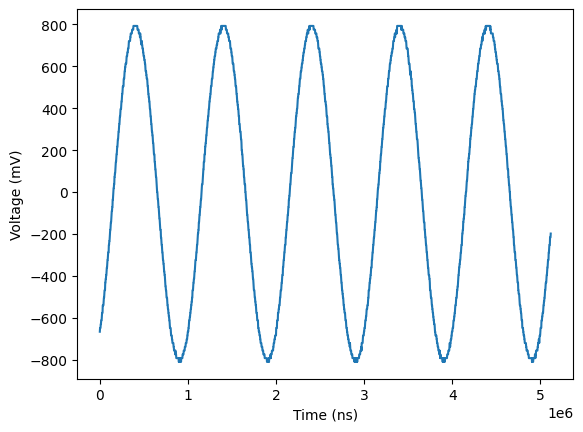

In [27]:

# plot data from channel A and B
plt.plot(time, adc2mVChA[:])
# plt.plot(time, adc2mVChB[:])
plt.xlabel('Time (ns)')
plt.ylabel('Voltage (mV)')
plt.show()

In [28]:
# Stop the scope
# handle = chandle
status["stop"] = ps.ps2000_stop(chandle)
assert_pico2000_ok(status["stop"])

# Close unitDisconnect the scope
# handle = chandle
status["close"] = ps.ps2000_close_unit(chandle)
assert_pico2000_ok(status["close"])

# display status returns
print(status)

{'openUnit': 1, 'setChA': 1, 'getTimebase': 1, 'runBlock': 1, 'isReady': 1, 'getValues': 2000, 'stop': 1, 'close': 1}
